Task 2: Customer Segmentation Using Unsupervised Learning

Objective: Cluster mall customers based on their spending habits to propose tailored marketing strategies.
Dataset: Mall Customers Dataset (includes Age, Annual Income, and Spending Score).
Approach: We will perform Exploratory Data Analysis (EDA), use the Elbow Method to find the optimal number of clusters, and apply the K-Means algorithm to segment the customers.

In [2]:
# Import the standard data science libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Mall Customers dataset directly from a reliable Kaggle-sourced repository
url = 'https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv'
df = pd.read_csv(url)

# 1. Display basic information about the dataset (rows, columns, data types)
print("--- Dataset Info ---")
df.info()

# 2. Check for any missing/blank values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Display the first 5 rows to see the actual data
print("\n--- First 5 Rows ---")
display(df.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

--- Missing Values ---
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

--- First 5 Rows ---


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


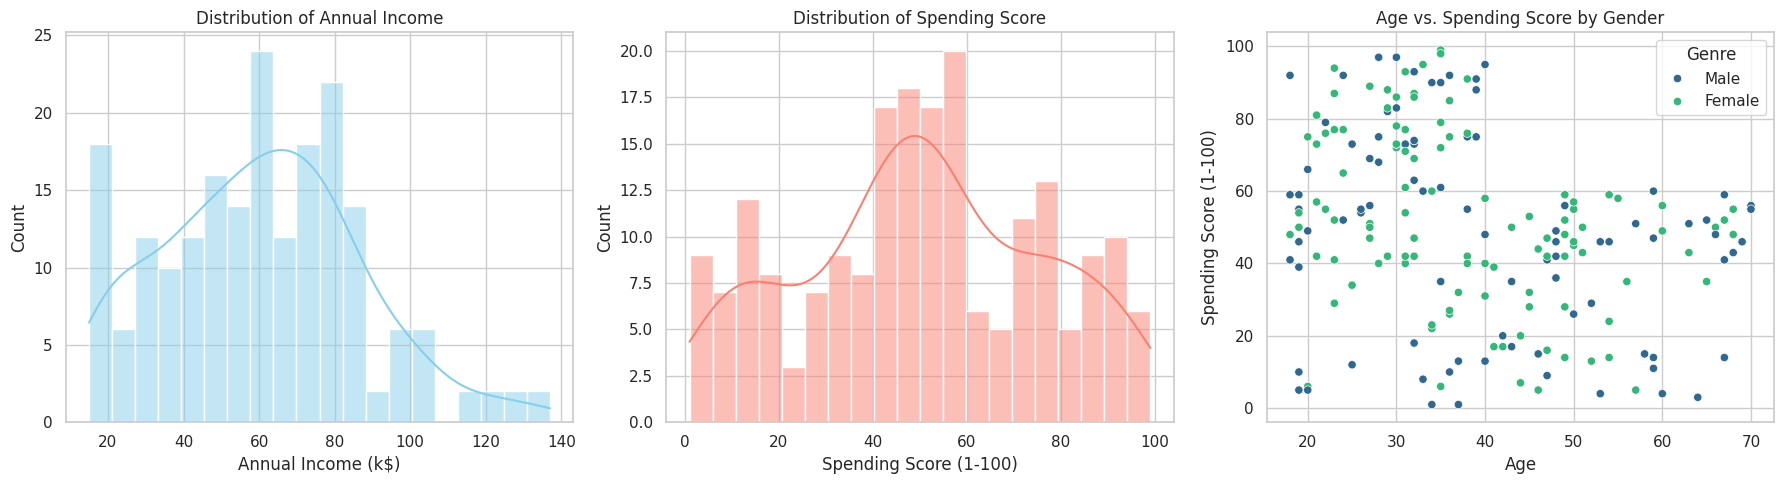

In [3]:
# Set up a clean visual style
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of Annual Income
sns.histplot(ax=axes[0], data=df, x='Annual Income (k$)', bins=20, kde=True, color='skyblue')
axes[0].set_title('Distribution of Annual Income')

# 2. Distribution of Spending Score
sns.histplot(ax=axes[1], data=df, x='Spending Score (1-100)', bins=20, kde=True, color='salmon')
axes[1].set_title('Distribution of Spending Score')

# 3. Scatter plot: Age vs. Spending Score categorized by Gender (Genre)
sns.scatterplot(ax=axes[2], data=df, x='Age', y='Spending Score (1-100)', hue='Genre', palette='viridis')
axes[2].set_title('Age vs. Spending Score by Gender')

plt.tight_layout()
plt.show()

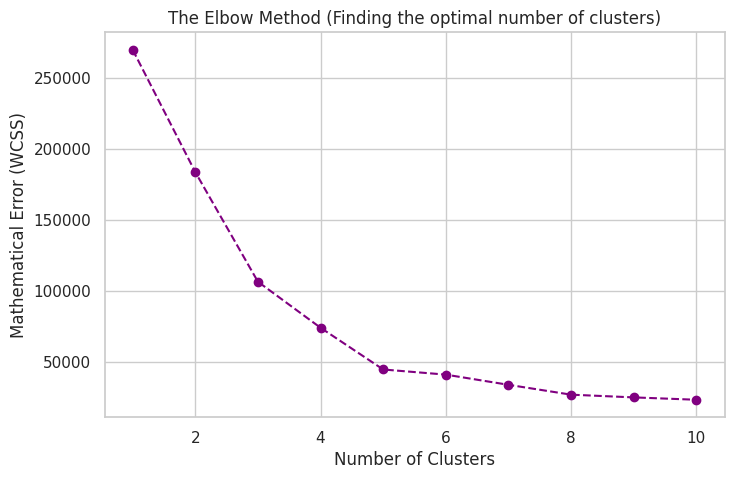

In [4]:
from sklearn.cluster import KMeans

# 1. We isolate the two most important business features: Income and Spending
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# 2. We run the algorithm 10 times to test different cluster amounts
wcss = [] # This stores the mathematical "error" rate
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# 3. Plot the results on a line graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='purple')
plt.title('The Elbow Method (Finding the optimal number of clusters)')
plt.xlabel('Number of Clusters')
plt.ylabel('Mathematical Error (WCSS)')
plt.show()

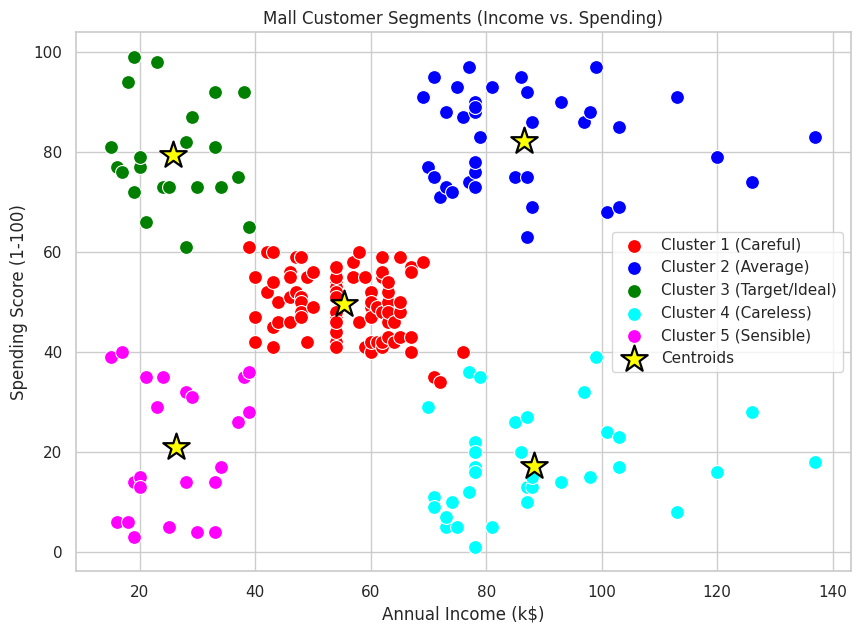

In [5]:
# 1. Train the K-Means model with our newly discovered optimal number of clusters (5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

# This physically groups the customers and gives each one a label (0, 1, 2, 3, or 4)
y_kmeans = kmeans.fit_predict(X)

# 2. Add these new labels back into our original dataframe so we know who is who
df['Cluster'] = y_kmeans

# 3. Visualize the 5 clusters using a color-coded scatter plot
plt.figure(figsize=(10, 7))

# We plot each of the 5 clusters one by one, assigning them business-friendly names
sns.scatterplot(x=X[y_kmeans == 0, 0], y=X[y_kmeans == 0, 1], s=100, color='red', label='Cluster 1 (Careful)')
sns.scatterplot(x=X[y_kmeans == 1, 0], y=X[y_kmeans == 1, 1], s=100, color='blue', label='Cluster 2 (Average)')
sns.scatterplot(x=X[y_kmeans == 2, 0], y=X[y_kmeans == 2, 1], s=100, color='green', label='Cluster 3 (Target/Ideal)')
sns.scatterplot(x=X[y_kmeans == 3, 0], y=X[y_kmeans == 3, 1], s=100, color='cyan', label='Cluster 4 (Careless)')
sns.scatterplot(x=X[y_kmeans == 4, 0], y=X[y_kmeans == 4, 1], s=100, color='magenta', label='Cluster 5 (Sensible)')

# Plot the mathematical centers (centroids) of each cluster as a giant yellow star
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], s=400, color='yellow', marker='*', edgecolor='black', label='Centroids')

plt.title('Mall Customer Segments (Income vs. Spending)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Conclusion and Marketing Strategies

Through K-Means clustering, we successfully segmented the mall's customer base into 5 distinct profiles. Based on their income and spending behaviors, here are the proposed marketing strategies for each segment:

    Segment 1: Average Customers (Middle Income / Middle Spenders)
    Strategy: Engage them with standard loyalty programs and seasonal discount alerts to maintain their steady foot traffic.

    Segment 2: VIP Customers (High Income / High Spenders)
    Strategy: Target them with premium, luxury brand advertisements and exclusive early-access shopping events. Do not offer steep discounts, as they are willing to pay full price.

    Segment 3: Frugal Customers (High Income / Low Spenders)
    Strategy: Focus on high-value, durable goods. They have the money but need to be convinced of the quality and longevity of the product before purchasing.

    Segment 4: Impulse Buyers (Low Income / High Spenders)
    Strategy: Target them with flashy, trendy, and affordable items. Flash sales and limited-time offers work best here.

    Segment 5: Sensible Customers (Low Income / Low Spenders)
    Strategy: Target them with clearance sales, buy-one-get-one-free offers, and extreme budget-friendly promotions.